# Check gpu

In [1]:
import torch
print(torch.cuda.get_device_name(0))
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CUDA: {torch.version.cuda}")

NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.3 GB
CUDA: 12.1


# Import thư viện

In [2]:
import torch, timm, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from torchmetrics import Accuracy, ConfusionMatrix
from sklearn.model_selection import train_test_split
from albumentations import Compose, HorizontalFlip, VerticalFlip, Rotate, ColorJitter, RandomResizedCrop
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from torchvision.datasets import ImageFolder
from torchvision import transforms
from collections import Counter
from PIL import Image
import os
from torchvision.transforms import v2
from torch.utils.data import random_split
from torch.utils.data import Subset

d:\Documents\KimTin\Fuzzy_Integral_Ear\OtoViT_Ensemble\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load dataset

In [3]:
DATA_DIR = Path("D:/Documents/KimTin/Fuzzy_Integral_Ear/OtoViT_Ensemble/data/raw/Oto-Endoscopic_Images/")
dataset = ImageFolder(root=DATA_DIR)
classes = dataset.classes
print(classes)

['Acute_Otitis_Media', 'Cerumen_Impaction', 'Chronic_Otitis_Media', 'Myringosclerosis', 'Normal']


# EDA

In [4]:
print(f"Total classes: {len(classes)}")
print(f"Total images: {len(dataset)}")

Total classes: 5
Total images: 3014


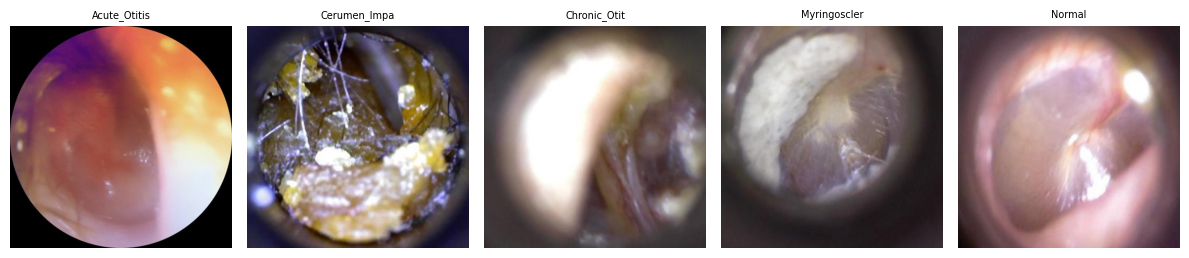

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, cls in enumerate(classes):
    idx = [j for j, (_, l) in enumerate(dataset.samples) if l == i][0]
    img = Image.open(dataset.samples[idx][0]).convert("RGB")
    axes[i].imshow(np.array(img))
    axes[i].set_title(cls[:12], fontsize=7)
    axes[i].axis("off")
plt.tight_layout(); plt.show()

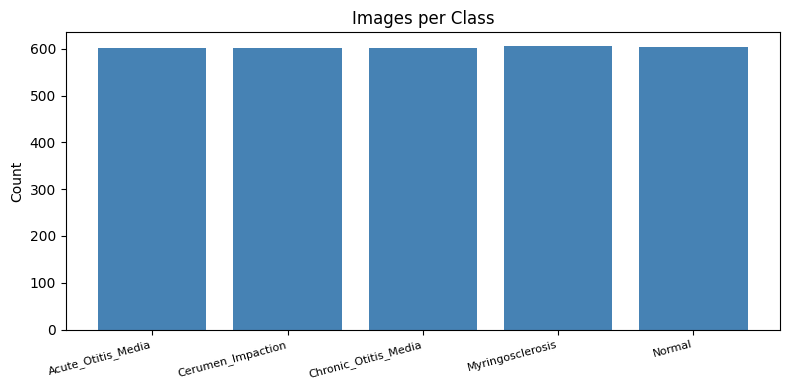

In [6]:
labels = [s[1] for s in dataset.samples]
counts = Counter(labels)
plt.figure(figsize=(8, 4))
plt.bar(classes, [counts[i] for i in range(len(classes))], color='steelblue')
plt.xticks(rotation=15, ha='right', fontsize=8)
plt.ylabel("Count"); plt.title("Images per Class")
plt.tight_layout(); plt.show()

# Tiền xử lý + Augmentation

In [7]:
train_tf = v2.Compose([
    v2.RandomResizedCrop(224), v2.RandomHorizontalFlip(0.5),
    v2.RandomVerticalFlip(0.5), v2.RandomRotation(30),
    v2.ColorJitter(0.4, 0.4, 0.4, 0.1),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    v2.RandomErasing(p=0.3),
])
val_tf = v2.Compose([
    v2.Resize(256), v2.CenterCrop(224), v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

In [8]:
all_ds = ImageFolder(DATA_DIR)
indices = list(range(len(all_ds)))
labels  = [s[1] for s in all_ds.samples]

tr_idx, tmp_idx = train_test_split(indices, test_size=0.2, stratify=labels, random_state=42)
tmp_labels = [labels[i] for i in tmp_idx]
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.5, stratify=tmp_labels, random_state=42)

train_ds = Subset(ImageFolder(DATA_DIR, transform=train_tf), tr_idx)
val_ds   = Subset(ImageFolder(DATA_DIR, transform=val_tf),   val_idx)
test_ds  = Subset(ImageFolder(DATA_DIR, transform=val_tf),   test_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 2411 | Val: 301 | Test: 302


# Siêu tham số tối ưu cho từng model

In [9]:
configs = {
    "swin_t":        {"lr": 1e-4, "batch": 32, "epochs": 30, "opt": "AdamW", "wd": 1e-2, "warmup": 5},
    "deit_small":    {"lr": 5e-4, "batch": 32, "epochs": 30, "opt": "AdamW", "wd": 1e-2, "warmup": 5},
    "coat_lite_small": {"lr": 1e-4, "batch": 16, "epochs": 30, "opt": "AdamW", "wd": 1e-2, "warmup": 5},
    "vit_base_16":   {"lr": 5e-5, "batch": 16, "epochs": 30, "opt": "AdamW", "wd": 1e-2, "warmup": 5},
    "beit_base": {"lr": 5e-5, "batch": 16, "epochs": 30, "opt": "AdamW", "wd": 1e-2, "warmup": 5},
    "maxvit_t":      {"lr": 1e-4, "batch": 16, "epochs": 30, "opt": "AdamW", "wd": 1e-2, "warmup": 5},
}
for k, v in configs.items(): print(f"{k}: {v}")

swin_t: {'lr': 0.0001, 'batch': 32, 'epochs': 30, 'opt': 'AdamW', 'wd': 0.01, 'warmup': 5}
deit_small: {'lr': 0.0005, 'batch': 32, 'epochs': 30, 'opt': 'AdamW', 'wd': 0.01, 'warmup': 5}
coat_lite_small: {'lr': 0.0001, 'batch': 16, 'epochs': 30, 'opt': 'AdamW', 'wd': 0.01, 'warmup': 5}
vit_base_16: {'lr': 5e-05, 'batch': 16, 'epochs': 30, 'opt': 'AdamW', 'wd': 0.01, 'warmup': 5}
beit_base: {'lr': 5e-05, 'batch': 16, 'epochs': 30, 'opt': 'AdamW', 'wd': 0.01, 'warmup': 5}
maxvit_t: {'lr': 0.0001, 'batch': 16, 'epochs': 30, 'opt': 'AdamW', 'wd': 0.01, 'warmup': 5}


# Training Pipeline

In [10]:
from torch.cuda.amp import GradScaler, autocast

def train_model(model, cfg, name):
    cutmix = v2.CutMix(num_classes=5, alpha=1.0)
    mixup  = v2.MixUp(num_classes=5, alpha=0.8)
    cm_fn  = lambda b: cutmix(b) if torch.rand(1)<0.5 else mixup(b)
    opt    = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    scaler = GradScaler()
    loss_fn= nn.CrossEntropyLoss(label_smoothing=0.1)
    model.to("cuda"); best, history = 0, {"tl":[],"ta":[],"vl":[],"va":[]}
    for ep in range(cfg["epochs"]):
        model.train(); tl, tc, tt = 0,0,0
        for x, y in train_loader:
            x, y = cm_fn((x.cuda(), y.cuda()))
            opt.zero_grad()
            with autocast():
                out = model(x); loss = loss_fn(out, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl+=loss.item(); tc+=(out.argmax(1)==y.argmax(1)).sum().item(); tt+=len(y)
        model.eval(); vl, vc, vt = 0,0,0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.cuda(), y.cuda()
                with autocast(): out = model(x); loss = loss_fn(out, y)
                vl+=loss.item(); vc+=(out.argmax(1)==y).sum().item(); vt+=len(y)
        sched.step()
        ta, va = tc/tt, vc/vt
        history["tl"].append(tl/len(train_loader)); history["ta"].append(ta)
        history["vl"].append(vl/len(val_loader));   history["va"].append(va)
        print(f"[{name}] Ep{ep+1} | Loss:{tl/len(train_loader):.3f} | TAcc:{ta:.3f} | VAcc:{va:.3f}")
        if va > best:
            best = va; torch.save(model.state_dict(), f"../models/{name}_best.pth")
    print(f"{name} Best Val Acc: {best:.4f}"); return history

# Huấn luyện Swin-T

In [11]:
model_swint = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=5)
hist_swint  = train_model(model_swint, configs["swin_t"], "swin_t")

C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): out = model(x); loss = loss_fn(out, y)


[swin_t] Ep1 | Loss:1.184 | TAcc:0.628 | VAcc:0.963
[swin_t] Ep2 | Loss:0.962 | TAcc:0.773 | VAcc:0.977
[swin_t] Ep3 | Loss:0.961 | TAcc:0.799 | VAcc:0.987
[swin_t] Ep4 | Loss:0.953 | TAcc:0.800 | VAcc:0.967
[swin_t] Ep5 | Loss:0.861 | TAcc:0.848 | VAcc:0.997
[swin_t] Ep6 | Loss:0.876 | TAcc:0.839 | VAcc:0.997
[swin_t] Ep7 | Loss:0.885 | TAcc:0.839 | VAcc:0.997
[swin_t] Ep8 | Loss:0.849 | TAcc:0.866 | VAcc:0.997
[swin_t] Ep9 | Loss:0.839 | TAcc:0.877 | VAcc:0.997
[swin_t] Ep10 | Loss:0.841 | TAcc:0.881 | VAcc:1.000
[swin_t] Ep11 | Loss:0.856 | TAcc:0.866 | VAcc:0.997
[swin_t] Ep12 | Loss:0.822 | TAcc:0.893 | VAcc:1.000
[swin_t] Ep13 | Loss:0.784 | TAcc:0.915 | VAcc:1.000
[swin_t] Ep14 | Loss:0.840 | TAcc:0.890 | VAcc:1.000
[swin_t] Ep15 | Loss:0.817 | TAcc:0.895 | VAcc:1.000
[swin_t] Ep16 | Loss:0.831 | TAcc:0.893 | VAcc:1.000
[swin_t] Ep17 | Loss:0.808 | TAcc:0.916 | VAcc:1.000
[swin_t] Ep18 | Loss:0.814 | TAcc:0.911 | VAcc:1.000
[swin_t] Ep19 | Loss:0.791 | TAcc:0.900 | VAcc:1.000
[s

# Huấn luyện CoaT-Lite Small

In [12]:
model_coat = timm.create_model("coat_lite_small", pretrained=True, num_classes=5)
hist_coat  = train_model(model_coat, configs["coat_lite_small"], "coat_lite_small")

C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): out = model(x); loss = loss_fn(out, y)


[coat_lite_small] Ep1 | Loss:1.120 | TAcc:0.676 | VAcc:0.914
[coat_lite_small] Ep2 | Loss:0.889 | TAcc:0.837 | VAcc:0.997
[coat_lite_small] Ep3 | Loss:0.893 | TAcc:0.844 | VAcc:1.000
[coat_lite_small] Ep4 | Loss:0.875 | TAcc:0.859 | VAcc:0.997
[coat_lite_small] Ep5 | Loss:0.869 | TAcc:0.858 | VAcc:1.000
[coat_lite_small] Ep6 | Loss:0.832 | TAcc:0.891 | VAcc:1.000
[coat_lite_small] Ep7 | Loss:0.836 | TAcc:0.885 | VAcc:1.000
[coat_lite_small] Ep8 | Loss:0.824 | TAcc:0.892 | VAcc:1.000
[coat_lite_small] Ep9 | Loss:0.825 | TAcc:0.872 | VAcc:1.000
[coat_lite_small] Ep10 | Loss:0.797 | TAcc:0.909 | VAcc:1.000
[coat_lite_small] Ep11 | Loss:0.812 | TAcc:0.887 | VAcc:1.000
[coat_lite_small] Ep12 | Loss:0.819 | TAcc:0.878 | VAcc:1.000
[coat_lite_small] Ep13 | Loss:0.814 | TAcc:0.913 | VAcc:1.000
[coat_lite_small] Ep14 | Loss:0.788 | TAcc:0.915 | VAcc:1.000
[coat_lite_small] Ep15 | Loss:0.825 | TAcc:0.876 | VAcc:1.000
[coat_lite_small] Ep16 | Loss:0.760 | TAcc:0.942 | VAcc:1.000
[coat_lite_small]

# Huấn luyện DeiT-S

In [13]:
model_deit = timm.create_model("deit_small_patch16_224", pretrained=True, num_classes=5)
hist_deit  = train_model(model_deit, configs["deit_small"], "deit_small")

C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): out = model(x); loss = loss_fn(out, y)


[deit_small] Ep1 | Loss:1.438 | TAcc:0.428 | VAcc:0.734
[deit_small] Ep2 | Loss:1.243 | TAcc:0.592 | VAcc:0.870
[deit_small] Ep3 | Loss:1.229 | TAcc:0.591 | VAcc:0.834
[deit_small] Ep4 | Loss:1.175 | TAcc:0.653 | VAcc:0.934
[deit_small] Ep5 | Loss:1.089 | TAcc:0.706 | VAcc:0.947
[deit_small] Ep6 | Loss:1.098 | TAcc:0.720 | VAcc:0.934
[deit_small] Ep7 | Loss:1.100 | TAcc:0.713 | VAcc:0.940
[deit_small] Ep8 | Loss:1.025 | TAcc:0.751 | VAcc:0.967
[deit_small] Ep9 | Loss:1.047 | TAcc:0.747 | VAcc:0.983
[deit_small] Ep10 | Loss:1.002 | TAcc:0.782 | VAcc:0.990
[deit_small] Ep11 | Loss:1.027 | TAcc:0.767 | VAcc:0.993
[deit_small] Ep12 | Loss:0.955 | TAcc:0.806 | VAcc:0.970
[deit_small] Ep13 | Loss:1.030 | TAcc:0.760 | VAcc:0.973
[deit_small] Ep14 | Loss:0.926 | TAcc:0.815 | VAcc:1.000
[deit_small] Ep15 | Loss:0.971 | TAcc:0.809 | VAcc:0.983
[deit_small] Ep16 | Loss:0.966 | TAcc:0.781 | VAcc:0.997
[deit_small] Ep17 | Loss:0.952 | TAcc:0.815 | VAcc:0.997
[deit_small] Ep18 | Loss:0.913 | TAcc:0.

# Huấn luyện ViT-B/16

In [14]:
model_vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=5)
hist_vit  = train_model(model_vit, configs["vit_base_16"], "vit_base_16")

C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): out = model(x); loss = loss_fn(out, y)


[vit_base_16] Ep1 | Loss:1.187 | TAcc:0.645 | VAcc:0.920
[vit_base_16] Ep2 | Loss:0.981 | TAcc:0.799 | VAcc:1.000
[vit_base_16] Ep3 | Loss:0.932 | TAcc:0.817 | VAcc:0.983
[vit_base_16] Ep4 | Loss:0.866 | TAcc:0.854 | VAcc:0.997
[vit_base_16] Ep5 | Loss:0.833 | TAcc:0.881 | VAcc:0.990
[vit_base_16] Ep6 | Loss:0.853 | TAcc:0.860 | VAcc:1.000
[vit_base_16] Ep7 | Loss:0.877 | TAcc:0.847 | VAcc:1.000
[vit_base_16] Ep8 | Loss:0.861 | TAcc:0.856 | VAcc:1.000
[vit_base_16] Ep9 | Loss:0.816 | TAcc:0.885 | VAcc:1.000
[vit_base_16] Ep10 | Loss:0.810 | TAcc:0.898 | VAcc:1.000
[vit_base_16] Ep11 | Loss:0.854 | TAcc:0.879 | VAcc:1.000
[vit_base_16] Ep12 | Loss:0.848 | TAcc:0.893 | VAcc:1.000
[vit_base_16] Ep13 | Loss:0.786 | TAcc:0.910 | VAcc:1.000
[vit_base_16] Ep14 | Loss:0.814 | TAcc:0.903 | VAcc:1.000
[vit_base_16] Ep15 | Loss:0.796 | TAcc:0.897 | VAcc:1.000
[vit_base_16] Ep16 | Loss:0.792 | TAcc:0.918 | VAcc:1.000
[vit_base_16] Ep17 | Loss:0.760 | TAcc:0.929 | VAcc:1.000
[vit_base_16] Ep18 | Lo

# Huấn luyện BEiT-B

In [15]:
model_beit = timm.create_model("beit_base_patch16_224", pretrained=True, num_classes=5)
hist_beit  = train_model(model_beit, configs["beit_base"], "beit_base")

C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): out = model(x); loss = loss_fn(out, y)


[beit_base] Ep1 | Loss:1.371 | TAcc:0.492 | VAcc:0.804
[beit_base] Ep2 | Loss:1.163 | TAcc:0.666 | VAcc:0.960
[beit_base] Ep3 | Loss:1.049 | TAcc:0.752 | VAcc:0.990
[beit_base] Ep4 | Loss:0.997 | TAcc:0.786 | VAcc:0.990
[beit_base] Ep5 | Loss:0.960 | TAcc:0.806 | VAcc:0.997
[beit_base] Ep6 | Loss:0.919 | TAcc:0.835 | VAcc:0.983
[beit_base] Ep7 | Loss:0.894 | TAcc:0.827 | VAcc:0.997
[beit_base] Ep8 | Loss:0.929 | TAcc:0.842 | VAcc:1.000
[beit_base] Ep9 | Loss:0.844 | TAcc:0.878 | VAcc:0.987
[beit_base] Ep10 | Loss:0.847 | TAcc:0.883 | VAcc:1.000
[beit_base] Ep11 | Loss:0.853 | TAcc:0.891 | VAcc:1.000
[beit_base] Ep12 | Loss:0.820 | TAcc:0.911 | VAcc:1.000
[beit_base] Ep13 | Loss:0.827 | TAcc:0.906 | VAcc:1.000
[beit_base] Ep14 | Loss:0.856 | TAcc:0.884 | VAcc:1.000
[beit_base] Ep15 | Loss:0.814 | TAcc:0.896 | VAcc:1.000
[beit_base] Ep16 | Loss:0.845 | TAcc:0.888 | VAcc:1.000
[beit_base] Ep17 | Loss:0.831 | TAcc:0.899 | VAcc:1.000
[beit_base] Ep18 | Loss:0.836 | TAcc:0.897 | VAcc:1.000
[

# Huấn luyện MaxViT-T

In [16]:
model_maxvit = timm.create_model("maxvit_tiny_tf_224.in1k", pretrained=True, num_classes=5)
hist_maxvit  = train_model(model_maxvit, configs["maxvit_t"], "maxvit_t")

C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Acer\AppData\Local\Temp\ipykernel_15600\1992477124.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): out = model(x); loss = loss_fn(out, y)


[maxvit_t] Ep1 | Loss:1.247 | TAcc:0.606 | VAcc:0.801
[maxvit_t] Ep2 | Loss:1.015 | TAcc:0.761 | VAcc:0.973
[maxvit_t] Ep3 | Loss:0.941 | TAcc:0.813 | VAcc:0.990
[maxvit_t] Ep4 | Loss:0.931 | TAcc:0.824 | VAcc:0.987
[maxvit_t] Ep5 | Loss:0.851 | TAcc:0.866 | VAcc:0.983
[maxvit_t] Ep6 | Loss:0.886 | TAcc:0.848 | VAcc:0.990
[maxvit_t] Ep7 | Loss:0.869 | TAcc:0.848 | VAcc:1.000
[maxvit_t] Ep8 | Loss:0.850 | TAcc:0.860 | VAcc:1.000
[maxvit_t] Ep9 | Loss:0.839 | TAcc:0.866 | VAcc:1.000
[maxvit_t] Ep10 | Loss:0.821 | TAcc:0.891 | VAcc:1.000
[maxvit_t] Ep11 | Loss:0.830 | TAcc:0.852 | VAcc:1.000
[maxvit_t] Ep12 | Loss:0.809 | TAcc:0.896 | VAcc:1.000
[maxvit_t] Ep13 | Loss:0.845 | TAcc:0.907 | VAcc:1.000
[maxvit_t] Ep14 | Loss:0.791 | TAcc:0.898 | VAcc:1.000
[maxvit_t] Ep15 | Loss:0.807 | TAcc:0.900 | VAcc:1.000
[maxvit_t] Ep16 | Loss:0.808 | TAcc:0.912 | VAcc:1.000
[maxvit_t] Ep17 | Loss:0.803 | TAcc:0.888 | VAcc:1.000
[maxvit_t] Ep18 | Loss:0.775 | TAcc:0.907 | VAcc:1.000
[maxvit_t] Ep19 | L

# Accuracy 6 model trên Test Set

In [17]:
def eval_model(model, name):
    model.eval(); correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.cuda(), y.cuda()
            with torch.amp.autocast('cuda'):
                out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += len(y)
    acc = correct / total
    print(f"{name}: Test Acc = {acc:.4f} ({correct}/{total})")
    return acc

results = {}
for model, name in [(model_swint,"Swin-T"), (model_deit,"DeiT-S"),
                    (model_coat,"CoaT-S"), (model_vit,"ViT-B/16"),
                    (model_beit,"BEiT-B"), (model_maxvit,"MaxViT-T")]:
    results[name] = eval_model(model, name)

Swin-T: Test Acc = 1.0000 (302/302)
DeiT-S: Test Acc = 0.9934 (300/302)
CoaT-S: Test Acc = 1.0000 (302/302)
ViT-B/16: Test Acc = 1.0000 (302/302)
BEiT-B: Test Acc = 1.0000 (302/302)
MaxViT-T: Test Acc = 1.0000 (302/302)


# Confusion Matrix Grid 6 model

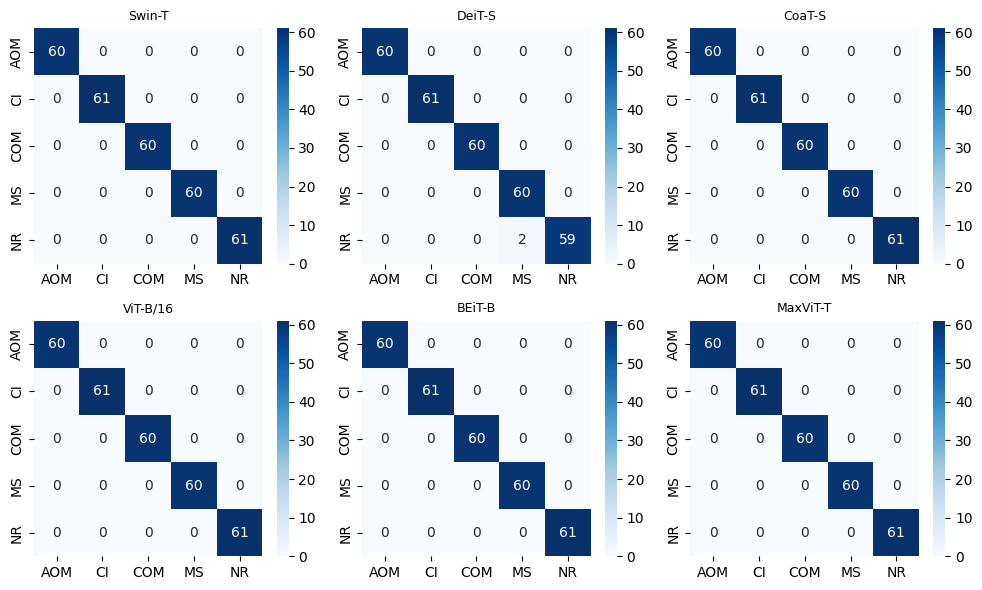

In [18]:
def get_cm(model):
    cm = ConfusionMatrix(task="multiclass", num_classes=5).to("cuda")
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.cuda(), y.cuda()
            with torch.amp.autocast('cuda'): out = model(x)
            cm.update(out.argmax(1), y)
    return cm.compute().cpu().numpy()

models_list = [(model_swint,"Swin-T"),(model_deit,"DeiT-S"),
               (model_coat,"CoaT-S"),(model_vit,"ViT-B/16"),
               (model_beit,"BEiT-B"),(model_maxvit,"MaxViT-T")]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
short = ["AOM","CI","COM","MS","NR"]
for ax, (model, name) in zip(axes.flatten(), models_list):
    cm = get_cm(model)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=short, yticklabels=short)
    ax.set_title(name, fontsize=9)
plt.tight_layout(); plt.show()

# Plot Loss & Accuracy Curves 6 model

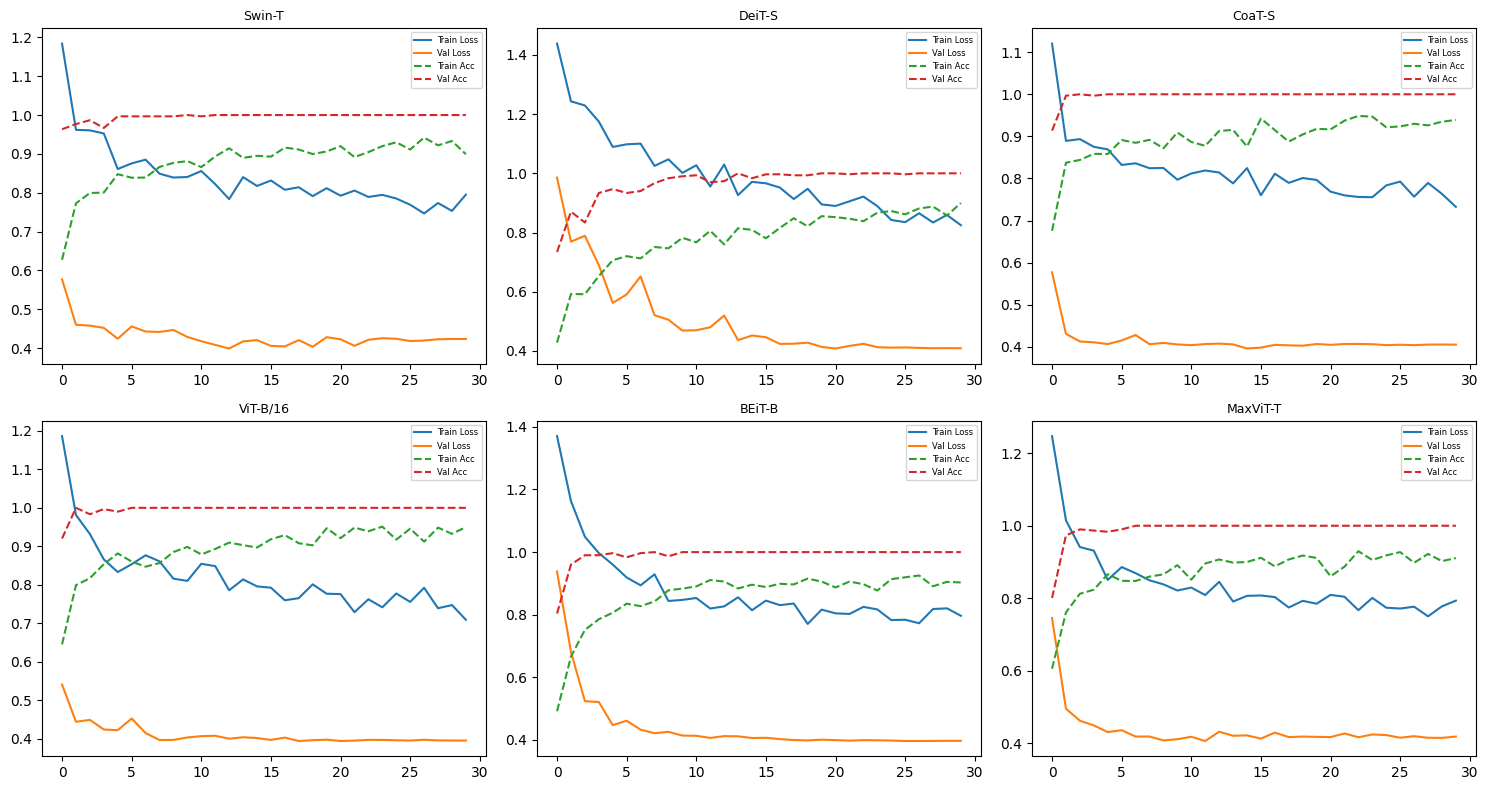

In [19]:
hists = [(hist_swint,"Swin-T"),(hist_deit,"DeiT-S"),
         (hist_coat,"CoaT-S"),(hist_vit,"ViT-B/16"),
         (hist_beit,"BEiT-B"),(hist_maxvit,"MaxViT-T")]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (h, name) in zip(axes.flatten(), hists):
    ax.plot(h["tl"], label="Train Loss")
    ax.plot(h["vl"], label="Val Loss")
    ax.plot(h["ta"], label="Train Acc", linestyle="--")
    ax.plot(h["va"], label="Val Acc",   linestyle="--")
    ax.set_title(name, fontsize=9); ax.legend(fontsize=6)
plt.tight_layout(); plt.show()

In [20]:
plt.savefig("../results/loss_acc_curves.png", dpi=150)

<Figure size 640x480 with 0 Axes>

# Save 6 model

In [21]:
os.makedirs("../models", exist_ok=True)

for model, name in [(model_swint,"swin_t"),(model_deit,"deit_small"),
                    (model_coat,"coat_lite_small"),(model_vit,"vit_base_16"),
                    (model_beit,"beit_base"),(model_maxvit,"maxvit_t")]:
    torch.save(model.state_dict(), f"../models/{name}_best.pth")
    print(f"Saved {name}_best.pth")

Saved swin_t_best.pth
Saved deit_small_best.pth
Saved coat_lite_small_best.pth
Saved vit_base_16_best.pth
Saved beit_base_best.pth
Saved maxvit_t_best.pth


# Load + Best Single + Hard Voting + Soft Voting

In [22]:
def get_preds(model):
    all_preds, all_probs, all_labels = [], [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            x = x.cuda()
            with torch.amp.autocast('cuda'): out = model(x)
            probs = torch.softmax(out, dim=1)
            all_probs.append(probs.cpu()); all_preds.append(probs.argmax(1).cpu()); all_labels.append(y)
    return torch.cat(all_preds), torch.cat(all_probs), torch.cat(all_labels)

preds, probs, labels = {}, {}, None
for model, name in models_list:
    p, pr, lb = get_preds(model)
    preds[name] = p; probs[name] = pr; labels = lb

In [23]:
names = list(preds.keys())
hard_vote = torch.stack([preds[n] for n in names]).mode(dim=0).values
soft_vote = torch.stack([probs[n] for n in names]).mean(dim=0).argmax(dim=1)

best_name = max(results, key=results.get)
print(f"Best Single ({best_name}): {results[best_name]:.4f}")
print(f"Hard Voting: {(hard_vote==labels).float().mean():.4f}")
print(f"Soft Voting: {(soft_vote==labels).float().mean():.4f}")

Best Single (Swin-T): 1.0000
Hard Voting: 1.0000
Soft Voting: 1.0000


# Choquet-Init μ({i}), λ, M=3

In [25]:
from scipy.optimize import brentq

top3 = sorted(results, key=results.get, reverse=True)[:3]
print("Top 3 models:", top3)
mu_single = {n: results[n] for n in top3}
mu_single = {n: v/sum(mu_single.values()) for n,v in mu_single.items()}
print("μ singletons:", mu_single)

def lambda_eq(lam, mus):
    return np.prod([1 + lam*m for m in mus]) - (1 + lam)

mus = list(mu_single.values())
try:
    lam = brentq(lambda_eq, -1+1e-9, 100, args=(mus,))
except ValueError:
    lam = 1e-9
print(f"λ = {lam:.6f}")

Top 3 models: ['Swin-T', 'CoaT-S', 'ViT-B/16']
μ singletons: {'Swin-T': 0.3333333333333333, 'CoaT-S': 0.3333333333333333, 'ViT-B/16': 0.3333333333333333}
λ = 0.000000


In [26]:
def fuzzy_measure(subset, lam, mu_s):
    if len(subset) == 0: return 0
    vals = [mu_s[s] for s in subset]
    return (np.prod([1 + lam*v for v in vals]) - 1) / lam

def choquet(scores, names, lam, mu_s):
    idx = np.argsort(scores)[::-1]
    sorted_scores = scores[idx]
    sorted_names  = [names[i] for i in idx]
    result, prev  = 0, 0
    for k in range(len(sorted_scores)):
        subset = sorted_names[k:]
        mu_val = fuzzy_measure(subset, lam, mu_s)
        result += (sorted_scores[k] - prev) * mu_val
        prev    = sorted_scores[k]
    return result

all_probs_np = {n: probs[n].numpy() for n in top3}
labels_np    = labels.numpy()
choquet_preds = []
for i in range(len(labels_np)):
    scores = np.array([all_probs_np[n][i].max() for n in top3])
    cls_votes = [all_probs_np[n][i].argmax() for n in top3]
    c_scores  = []
    for c in range(5):
        sc = np.array([all_probs_np[n][i][c] for n in top3])
        c_scores.append(choquet(sc, top3, lam, mu_single))
    choquet_preds.append(np.argmax(c_scores))

choquet_acc = (np.array(choquet_preds) == labels_np).mean()
print(f"Choquet-Init Acc: {choquet_acc:.4f}")

Choquet-Init Acc: 1.0000


# Choquet-Opt (2^N−2 values) M=3 (maybe GA)

In [ ]:
from itertools import combinations
from scipy.optimize import minimize

N = 3
subsets = []
for r in range(1, N+1):
    for s in combinations(range(N), r):
        subsets.append(s)
subset_idx = {s: i for i, s in enumerate(subsets)}
n_vars = len(subsets)  # 2^3 - 1 = 7

def get_mu(params, subset):
    if len(subset) == 0: return 0.0
    if len(subset) == N: return 1.0
    return params[subset_idx[tuple(sorted(subset))]]

def choquet_opt(scores, params):
    idx = np.argsort(scores)[::-1]
    s_scores = scores[idx]
    result, prev = 0, 0
    for k in range(len(s_scores)):
        subset = tuple(sorted(idx[k:]))
        mu_val = get_mu(params, subset)
        result += (s_scores[k] - prev) * mu_val
        prev    = s_scores[k]
    return result

def loss_fn(params):
    preds = []
    for i in range(len(labels_np)):
        c_scores = []
        for c in range(5):
            sc = np.array([all_probs_np[n][i][c] for n in top3])
            c_scores.append(choquet_opt(sc, params))
        preds.append(np.argmax(c_scores))
    return -np.mean(np.array(preds) == labels_np)

constraints, bounds = [], [(0,1)]*n_vars
for r in range(1, N):
    for s in combinations(range(N), r):
        for add in range(N):
            if add not in s:
                sup = tuple(sorted(s+(add,)))
                constraints.append({"type":"ineq",
                    "fun": lambda p, a=subset_idx[sup], b=subset_idx[s]: p[a]-p[b]})

x0 = np.array([list(mu_single.values())[i] if len(s)==1 else 0.5 for i, s in enumerate(subsets)])
x0 = np.clip(x0, 0.01, 0.99)
res = minimize(loss_fn, x0, bounds=bounds, constraints=constraints, method="SLSQP",
               options={"maxiter":200})
print(f"Choquet-Opt Acc: {-res.fun:.4f}")

IndexError: list index out of range

# Choquet-λ tự động tối ưu M=3

In [ ]:
def choquet_lambda(scores, lam, mu_s, names):
    def fm(subset):
        if len(subset) == 0: return 0
        if lam == 0: return sum(mu_s[names[i]] for i in subset)
        vals = [mu_s[names[i]] for i in subset]
        return (np.prod([1 + lam*v for v in vals]) - 1) / lam
    idx = np.argsort(scores)[::-1]
    s_scores = scores[idx]
    result, prev = 0, 0
    for k in range(len(s_scores)):
        subset = list(idx[k:])
        mu_val = fm(subset)
        result += (s_scores[k] - prev) * mu_val
        prev    = s_scores[k]
    return result

def eval_lambda(lam):
    preds = []
    for i in range(len(labels_np)):
        c_scores = []
        for c in range(5):
            sc = np.array([all_probs_np[n][i][c] for n in top3])
            c_scores.append(choquet_lambda(sc, lam, mu_single, top3))
        preds.append(np.argmax(c_scores))
    return np.mean(np.array(preds) == labels_np)

In [ ]:
lambdas = np.linspace(-0.99, 20, 200)
accs    = [eval_lambda(l) for l in lambdas]
best_lam = lambdas[np.argmax(accs)]
best_acc = max(accs)
print(f"Best λ = {best_lam:.4f} | Choquet-λ Acc: {best_acc:.4f}")

plt.plot(lambdas, accs)
plt.xlabel("λ"); plt.ylabel("Accuracy")
plt.title("Choquet-λ Accuracy vs λ"); plt.show()

# Sugeno Integral (max-min) μ({i}) M=3

In [ ]:
def sugeno_integral(scores, lam, mu_s, names):
    def fm(subset):
        if len(subset) == 0: return 0
        vals = [mu_s[names[i]] for i in subset]
        return (np.prod([1 + lam*v for v in vals]) - 1) / lam
    idx = np.argsort(scores)[::-1]
    s_scores = scores[idx]
    result = 0
    for k in range(len(s_scores)):
        subset = list(idx[k:])
        mu_val = fm(subset)
        result = max(result, min(s_scores[k], mu_val))
    return result

In [ ]:
sugeno_preds = []
for i in range(len(labels_np)):
    c_scores = []
    for c in range(5):
        sc = np.array([all_probs_np[n][i][c] for n in top3])
        c_scores.append(sugeno_integral(sc, lam, mu_single, top3))
    sugeno_preds.append(np.argmax(c_scores))

sugeno_acc = np.mean(np.array(sugeno_preds) == labels_np)
print(f"Sugeno Integral Acc: {sugeno_acc:.4f}")

# Final

In [ ]:
print("\n===== FINAL RESULTS =====")
print(f"Best Single ({best_name}): {results[best_name]:.4f}")
print(f"Hard Voting:      {(hard_vote==labels).float().mean():.4f}")
print(f"Soft Voting:      {(soft_vote==labels).float().mean():.4f}")
print(f"Choquet-Init:     {choquet_acc:.4f}")
print(f"Choquet-Opt:      {-res.fun:.4f}")
print(f"Choquet-λ Auto:   {best_acc:.4f}")
print(f"Sugeno Integral:  {sugeno_acc:.4f}")